In [1]:
import os, json, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.base import clone
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report, roc_curve, ConfusionMatrixDisplay)
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
MEMBER, STUDENT_ID, MODEL_NAME = 'Rathnayaka R.M.B.G.T.A.B.R.', 'IT25101550', 'Multi-Layer Perceptron (Neural Network)'
print(f'{MEMBER} ({STUDENT_ID}) - {MODEL_NAME}')

Rathnayaka R.M.B.G.T.A.B.R. (IT25101550) - Multi-Layer Perceptron (Neural Network)


In [2]:
# data loading and preprocessing
# load data
DATA = 'fitness_dataset.csv'
if not os.path.exists(DATA):
    try:
        from google.colab import files
        up = files.upload(); DATA = list(up.keys())[0]
    except ImportError:
        raise FileNotFoundError('Put fitness_dataset.csv next to this notebook.')
df = pd.read_csv(DATA)
print('Shape:', df.shape)
print(df.isnull().sum()[df.isnull().sum() > 0])
print(df['smokes'].value_counts().to_dict())
df.head()

Saving fitness_dataset.csv to fitness_dataset.csv
Shape: (2000, 11)
sleep_hours    160
dtype: int64
{'yes': 711, '0': 581, 'no': 518, '1': 190}


,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
0,56,152,65,69.6,117.0,NaN,2.37,3.97,no,F,1
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,F,1
2,46,192,103,61.4,116.4,NaN,8.20,2.03,0,F,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,M,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,yes,F,1


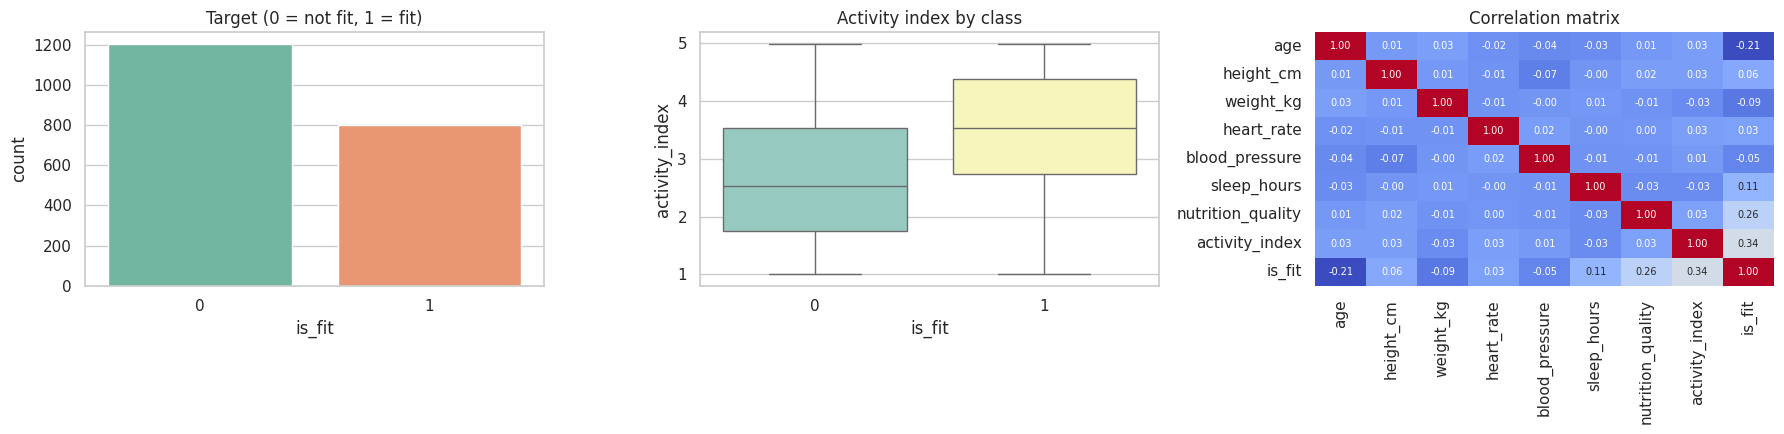

In [3]:
# eda
fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
sns.countplot(data=df, x='is_fit', palette='Set2', ax=ax[0]); ax[0].set_title('Target (0 = not fit, 1 = fit)')
sns.boxplot(data=df, x='is_fit', y='activity_index', palette='Set3', ax=ax[1]); ax[1].set_title('Activity index by class')
sns.heatmap(df.select_dtypes('number').corr(), annot=True, fmt='.2f', cmap='coolwarm', cbar=False, ax=ax[2], annot_kws={'size': 7}); ax[2].set_title('Correlation matrix')
plt.tight_layout(); plt.show()

In [4]:
# cleaning, features, split
d = df.copy()
d['smokes'] = d['smokes'].astype(str).str.lower().map({'yes': 1, '1': 1, 'no': 0, '0': 0})
d['gender'] = (d['gender'] == 'M').astype(int)
d['bmi'] = d['weight_kg'] / (d['height_cm'] / 100) ** 2

y = d['is_fit']
BASE_COLS = ['age', 'height_cm', 'weight_kg', 'heart_rate', 'blood_pressure', 'sleep_hours',
             'nutrition_quality', 'activity_index', 'smokes', 'gender']
X = d[BASE_COLS + ['bmi']]
print(y.value_counts(normalize=True).round(3).to_dict())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print('Train:', X_train.shape, '| Test:', X_test.shape)

{0: 0.6, 1: 0.4}
Train: (1600, 11) | Test: (400, 11)


In [5]:
# preprocessing variants
VARIANTS = {
 'V1 Median impute, no scaling'  : dict(cols=BASE_COLS,                                        scaler=None,       pca=False),
 'V2 Median + StandardScaler'    : dict(cols=BASE_COLS,                                        scaler='standard', pca=False),
 'V3 Median + RobustScaler'      : dict(cols=BASE_COLS,                                        scaler='robust',   pca=False),
 'V4 Standard + BMI feature'     : dict(cols=BASE_COLS + ['bmi'],                              scaler='standard', pca=False),
 'V5 Standard, gender removed'   : dict(cols=[c for c in BASE_COLS if c != 'gender'],          scaler='standard', pca=False),
 'V6 Standard + PCA (95% var)'  : dict(cols=BASE_COLS,                                        scaler='standard', pca=True),
}

def make_pipeline(v, clf):
    steps = [('imputer', SimpleImputer(strategy='median'))]
    if v['scaler'] == 'standard': steps.append(('scaler', StandardScaler()))
    if v['scaler'] == 'robust':   steps.append(('scaler', RobustScaler()))
    if v['pca']:                  steps.append(('pca', PCA(n_components=0.95, random_state=42)))
    steps.append(('clf', clf))
    return Pipeline(steps)

def get_scores(model, X_):
    return model.predict_proba(X_)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X_)

def evaluate(model, X_, y_):
    p = model.predict(X_)
    return dict(Accuracy=accuracy_score(y_, p), Precision=precision_score(y_, p), Recall=recall_score(y_, p),
                F1=f1_score(y_, p), ROC_AUC=roc_auc_score(y_, get_scores(model, X_)))

cv = KFold(n_splits=5, shuffle=True, random_state=42)
BASE = MLPClassifier(max_iter=500, early_stopping=True, n_iter_no_change=20, random_state=42)
print('Base estimator:', BASE)

Base estimator: MLPClassifier(early_stopping=True, max_iter=500, n_iter_no_change=20,
              random_state=42)


,#Features,CV F1 (mean),CV F1 (std),Test Acc,Test F1,Test AUC,Time (s)
Variant,,,,,,,
"V1 Median impute, no scaling",10,0.6783,0.0352,0.7525,0.6452,0.8052,1.9248
V2 Median + StandardScaler,10,0.7164,0.0174,0.7625,0.6667,0.8438,1.4154
V3 Median + RobustScaler,10,0.7105,0.0377,0.7800,0.6986,0.8496,1.6152
V4 Standard + BMI feature,11,0.7338,0.0126,0.7675,0.6951,0.8516,1.5033
"V5 Standard, gender removed",9,0.6979,0.0185,0.7600,0.6690,0.8256,1.2273
V6 Standard + PCA (95% var),10,0.7123,0.0233,0.7800,0.6835,0.8504,2.2977


Best preprocessing by 5-fold CV F1: V4 Standard + BMI feature


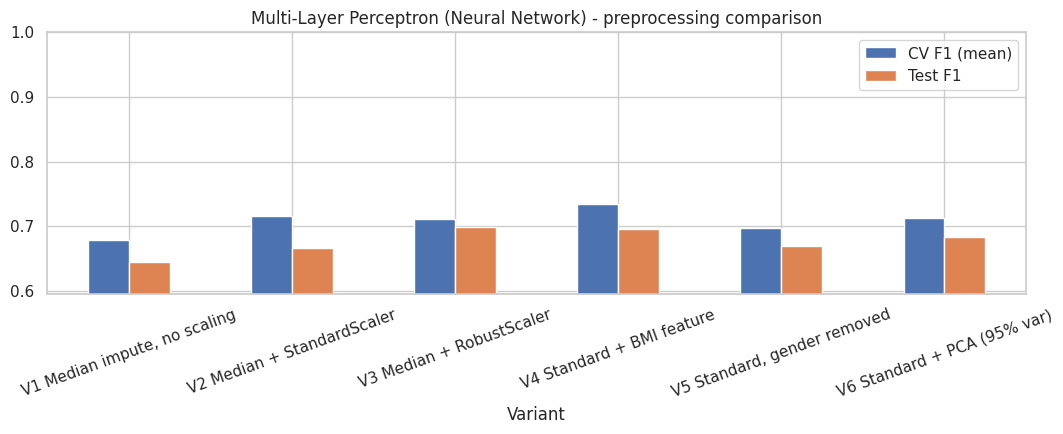

In [6]:
# preprocessing comparison, 5-fold cv
rows, n_fits = [], 0
for name, v in VARIANTS.items():
    t0 = time.time()
    pipe = make_pipeline(v, clone(BASE))
    cv_f1 = cross_val_score(pipe, X_train[v['cols']], y_train, cv=cv, scoring='f1'); n_fits += cv.get_n_splits()
    pipe.fit(X_train[v['cols']], y_train); n_fits += 1
    m = evaluate(pipe, X_test[v['cols']], y_test)
    rows.append({'Variant': name, '#Features': len(v['cols']), 'CV F1 (mean)': cv_f1.mean(), 'CV F1 (std)': cv_f1.std(),
                 'Test Acc': m['Accuracy'], 'Test F1': m['F1'], 'Test AUC': m['ROC_AUC'], 'Time (s)': time.time() - t0})
res_A = pd.DataFrame(rows).set_index('Variant')
display(res_A.round(4))
best_variant = res_A['CV F1 (mean)'].idxmax(); best_v = VARIANTS[best_variant]
print(f'Best preprocessing by 5-fold CV F1: {best_variant}')

ax = res_A[['CV F1 (mean)', 'Test F1']].plot.bar(figsize=(11, 4.5), rot=20, color=['#4c72b0', '#dd8452'])
ax.set_ylim(max(0, res_A[['CV F1 (mean)', 'Test F1']].min().min() - 0.05), 1); ax.set_title(f'{MODEL_NAME} - preprocessing comparison')
plt.tight_layout(); plt.show()

In [7]:
#hyperparameter tuning
# grid search
param_grid = {
    'clf__hidden_layer_sizes': [(32,), (64,), (64, 32)],
    'clf__alpha': [1e-4, 1e-2],
    'clf__learning_rate_init': [1e-3, 1e-2],
}
gs = GridSearchCV(make_pipeline(best_v, clone(BASE)), param_grid, cv=cv, scoring='f1', n_jobs=-1, refit=True, return_train_score=True)
t0 = time.time(); gs.fit(X_train[best_v['cols']], y_train)
n_combos = len(gs.cv_results_['params']); n_fits += n_combos * cv.get_n_splits() + 1
print(f'{n_combos} combinations x {cv.get_n_splits()} folds, {time.time()-t0:.0f}s')
print('Best params:', gs.best_params_); print(f'Best 5-fold CV F1: {gs.best_score_:.4f}')

cvr = pd.DataFrame(gs.cv_results_)
cols = [c for c in cvr.columns if c.startswith('param_')] + ['mean_train_score', 'mean_test_score', 'std_test_score', 'rank_test_score']
top = cvr[cols].sort_values('rank_test_score').head(8).rename(columns=lambda c: c.replace('param_clf__', ''))
top['overfit_gap'] = top['mean_train_score'] - top['mean_test_score']
display(top.round(4).reset_index(drop=True))

12 combinations x 5 folds, 14s
Best params: {'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (64, 32), 'clf__learning_rate_init': 0.01}
Best 5-fold CV F1: 0.7336


,alpha,hidden_layer_sizes,learning_rate_init,mean_train_score,mean_test_score,std_test_score,rank_test_score,overfit_gap
0,0.0001,"(64, 32)",0.010,0.7746,0.7336,0.0206,1,0.0410
1,0.0100,"(32,)",0.010,0.7533,0.7311,0.0317,2,0.0222
2,0.0001,"(32,)",0.010,0.7530,0.7310,0.0317,3,0.0220
3,0.0100,"(64, 32)",0.010,0.7917,0.7300,0.0156,4,0.0617
4,0.0100,"(64,)",0.010,0.7417,0.7278,0.0240,5,0.0139
5,0.0001,"(64,)",0.010,0.7416,0.7278,0.0240,5,0.0138
6,0.0001,"(64, 32)",0.001,0.7420,0.7128,0.0306,7,0.0292
7,0.0100,"(64, 32)",0.001,0.7418,0.7128,0.0306,7,0.0290


Multi-Layer Perceptron (Neural Network) | V4 Standard + BMI feature | {'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (64, 32), 'clf__learning_rate_init': 0.01}
  Accuracy: 0.7800
 Precision: 0.7118
    Recall: 0.7562
        F1: 0.7333
   ROC_AUC: 0.8456

              precision    recall  f1-score   support

     Not fit       0.83      0.80      0.81       240
         Fit       0.71      0.76      0.73       160

    accuracy                           0.78       400
   macro avg       0.77      0.78      0.77       400
weighted avg       0.78      0.78      0.78       400



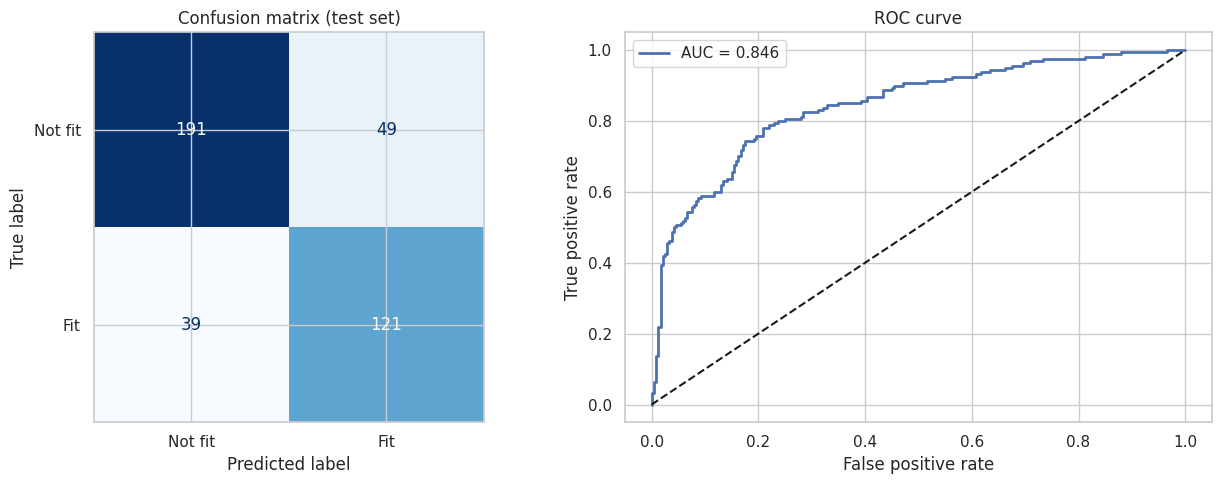

Train accuracy 0.8281 vs test accuracy 0.7800 (gap 0.0481)


In [8]:
#test set evaluation
# test set results
final_model = gs.best_estimator_
Xte = X_test[best_v['cols']]
final = evaluate(final_model, Xte, y_test)
print(f'{MODEL_NAME} | {best_variant} | {gs.best_params_}')
for k, v_ in final.items(): print(f'{k:>10}: {v_:.4f}')
print(); print(classification_report(y_test, final_model.predict(Xte), target_names=['Not fit', 'Fit']))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_estimator(final_model, Xte, y_test, display_labels=['Not fit', 'Fit'], cmap='Blues', ax=ax[0], colorbar=False)
ax[0].set_title('Confusion matrix (test set)')
fpr, tpr, _ = roc_curve(y_test, get_scores(final_model, Xte))
ax[1].plot(fpr, tpr, lw=2, label=f"AUC = {final['ROC_AUC']:.3f}"); ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_xlabel('False positive rate'); ax[1].set_ylabel('True positive rate'); ax[1].set_title('ROC curve'); ax[1].legend()
plt.tight_layout(); plt.show()

tr = evaluate(final_model, X_train[best_v['cols']], y_train)
print(f"Train accuracy {tr['Accuracy']:.4f} vs test accuracy {final['Accuracy']:.4f} (gap {tr['Accuracy']-final['Accuracy']:.4f})")

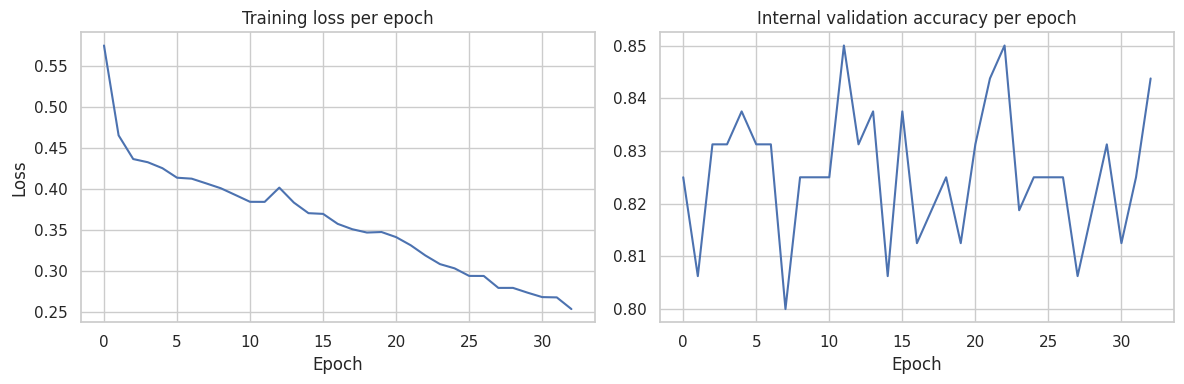

Epochs run: 33 | layers: (64, 32) | output activation: logistic


In [9]:
clf = final_model.named_steps['clf']
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].plot(clf.loss_curve_); ax[0].set_title('Training loss per epoch'); ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss')
ax[1].plot(clf.validation_scores_); ax[1].set_title('Internal validation accuracy per epoch'); ax[1].set_xlabel('Epoch')
plt.tight_layout(); plt.show()
print('Epochs run:', clf.n_iter_, '| layers:', clf.hidden_layer_sizes, '| output activation:', clf.out_activation_)

In [10]:
# stability check, 10 different random 80/20 splits
accs, f1s = [], []
for seed in range(10):
    Xa, Xb, ya, yb = train_test_split(X[best_v['cols']], y, test_size=0.20, random_state=seed, stratify=y)
    m_ = clone(final_model).fit(Xa, ya); n_fits += 1
    r_ = evaluate(m_, Xb, yb); accs.append(r_['Accuracy']); f1s.append(r_['F1'])
rep = dict(acc_mean=float(np.mean(accs)), acc_std=float(np.std(accs)), f1_mean=float(np.mean(f1s)), f1_std=float(np.std(f1s)),
           acc_min=float(np.min(accs)), acc_max=float(np.max(accs)))
print(f"Accuracy over 10 splits: {rep['acc_mean']:.4f} +/- {rep['acc_std']:.4f} (min {rep['acc_min']:.4f}, max {rep['acc_max']:.4f})")
print(f"F1 over 10 splits:       {rep['f1_mean']:.4f} +/- {rep['f1_std']:.4f}")

Accuracy over 10 splits: 0.7903 +/- 0.0173 (min 0.7625, max 0.8125)
F1 over 10 splits:       0.7294 +/- 0.0161


In [11]:
# summary and save results
total_configs = len(VARIANTS) + n_combos
print(f'Model: {MODEL_NAME}')
print(f'Configurations evaluated: {total_configs} ({len(VARIANTS)} preprocessing + {n_combos} hyperparameter combinations)')
print(f'Total fits incl. cross-validation: {n_fits}')
print(f'Best preprocessing: {best_variant}')
print(f'Best hyperparameters: {gs.best_params_}')
print(f"Test: Accuracy={final['Accuracy']:.4f} Precision={final['Precision']:.4f} Recall={final['Recall']:.4f} F1={final['F1']:.4f} AUC={final['ROC_AUC']:.4f}")

print('\n--- Conclusion ---')
print(f"Best preprocessing '{best_variant}' (CV F1 {res_A['CV F1 (mean)'].max():.4f}); worst '{res_A['CV F1 (mean)'].idxmin()}' ({res_A['CV F1 (mean)'].min():.4f}).")
print(f"Tuning moved test F1 from {res_A.loc[best_variant, 'Test F1']:.4f} to {final['F1']:.4f}.")
print(f"Train-test accuracy gap {tr['Accuracy']-final['Accuracy']:.4f}; accuracy over 10 splits {rep['acc_mean']:.4f} +/- {rep['acc_std']:.4f}.")

out = dict(member=MEMBER, student_id=STUDENT_ID, model=MODEL_NAME, best_variant=best_variant,
           best_params={k.replace('clf__', ''): (list(v_) if isinstance(v_, tuple) else v_) for k, v_ in gs.best_params_.items()},
           cv_f1=float(gs.best_score_), test={k: float(v_) for k, v_ in final.items()}, repeated=rep,
           train_acc=float(tr['Accuracy']), n_configs=int(total_configs), n_fits=int(n_fits),
           preprocessing_f1={k: float(v_) for k, v_ in res_A['CV F1 (mean)'].items()},
           preprocessing_test_acc={k: float(v_) for k, v_ in res_A['Test Acc'].items()})
with open(f'results_{STUDENT_ID}.json', 'w') as f: json.dump(out, f, indent=2, default=str)
print(f'Saved results_{STUDENT_ID}.json')

Model: Multi-Layer Perceptron (Neural Network)
Configurations evaluated: 18 (6 preprocessing + 12 hyperparameter combinations)
Total fits incl. cross-validation: 107
Best preprocessing: V4 Standard + BMI feature
Best hyperparameters: {'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (64, 32), 'clf__learning_rate_init': 0.01}
Test: Accuracy=0.7800 Precision=0.7118 Recall=0.7562 F1=0.7333 AUC=0.8456

--- Conclusion ---
Best preprocessing 'V4 Standard + BMI feature' (CV F1 0.7338); worst 'V1 Median impute, no scaling' (0.6783).
Tuning moved test F1 from 0.6951 to 0.7333.
Train-test accuracy gap 0.0481; accuracy over 10 splits 0.7903 +/- 0.0173.
Saved results_IT25101550.json
